# Isolation Forest implementation for unsupervised anomaly detection in HDFS system logs

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [48]:
import json
df_feat = pd.read_parquet("df_feat.parquet")

with open("hdfs_feat_cols.json", "r") as f:
    feat_cols = json.load(f)

X = df_feat[feat_cols].astype(float)
y = df_feat["y"].astype(int)   # only for evaluation/plots

print(df_feat.shape, X.shape, y.value_counts().to_dict())

(575061, 23) (575061, 21) {0: 558223, 1: 16838}


In [49]:
class HDFSIsolationForest:
    def __init__(self, contamination=0.1, random_state=42, n_estimators=100):
        """
        Initialize the Isolation Forest detector.
        
        Parameters:
        -----------
        contamination : float
            The expected proportion of outliers in the dataset (default: 0.1)
        random_state : int
            Random seed for reproducibility (default: 42)
        n_estimators : int
            Number of trees in the forest (default: 100)
        """
        self.contamination = contamination
        self.random_state = random_state
        self.n_estimators = n_estimators
        self.model = None
        self.scaler = StandardScaler()
        self.pca = None
        
    def fit(self, X):
        """
        Fit the Isolation Forest model on the data.
        
        Parameters:
        -----------
        X : array-like
            Training data
        """
        X_scaled = self.scaler.fit_transform(X)
        
        self.model = IsolationForest(
            contamination=self.contamination,
            random_state=self.random_state,
            n_estimators=self.n_estimators,
            max_samples='auto'
        )
        self.model.fit(X_scaled)
        return self

    def predict(self, X):
        """
        Predict anomalies (1 for normal, -1 for anomaly).
        
        Parameters:
        -----------
        X : array-like
            Data to predict
        
        Returns:
        --------
        predictions : array
            1 for normal, -1 for anomaly
        """
        X_scaled = self.scaler.transform(X)
        predictions = self.model.predict(X_scaled)
        return predictions
    
    def anomaly_scores(self, X):
        """
        Get anomaly scores (lower = more anomalous).
        
        Parameters:
        -----------
        X : array-like
            Data to score
        
        Returns:
        --------
        scores : array
            Anomaly scores
        """
        X_scaled = self.scaler.transform(X)
        return self.model.score_samples(X_scaled)
    
    def fit_predict(self, X):
        """
        Fit the model and return predictions.
        
        Parameters:
        -----------
        X : array-like
            Training data
        
        Returns:
        --------
        predictions : array
            1 for normal, -1 for anomaly
        """
        self.fit(X)
        return self.predict(X)

    @staticmethod
    def evaluate_performance(y_true, y_pred, anomaly_scores):
        """Standalone evaluator for external use."""
        y_pred_binary = (y_pred == -1).astype(int)
        cm = confusion_matrix(y_true, y_pred_binary)
        tn, fp, fn, tp = cm.ravel()
        accuracy = (tp + tn) / np.sum(cm)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        auc_score = roc_auc_score(y_true, anomaly_scores)
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        metrics = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1_score,
            'auc_score': auc_score,
            'specificity': specificity,
            'true_positives': tp,
            'true_negatives': tn,
            'false_positives': fp,
            'false_negatives': fn
        }

        print("="*60)
        print("ISOLATION FOREST - ANOMALY DETECTION RESULTS")
        print("="*60)
        print("\nClassification Report:")
        print("-"*60)
        print(classification_report(y_true, y_pred_binary,
                                    target_names=['Normal','Anomaly']))
        print("\nConfusion Matrix:")
        print("-"*60)
        print(f"                Predicted")
        print(f"                Normal  Anomaly")
        print(f"Actual Normal    {tn:5d}   {fp:5d}")
        print(f"Actual Anomaly   {fn:5d}   {tp:5d}")
        print("\nPerformance Metrics:")
        print("-"*60)
        print(f"Accuracy:      {accuracy:.4f}")
        print(f"Precision:     {precision:.4f}")
        print(f"Recall:        {recall:.4f}")
        print(f"F1-Score:      {f1_score:.4f}")
        print(f"Specificity:   {specificity:.4f}")
        print(f"AUC-ROC:       {auc_score:.4f}")
        print("="*60)
        return metrics

In [58]:
def visualize_results(X, y_true, y_pred, anomaly_scores, save_path="figures/"):
    """Create visualizations for Isolation Forest results.

    Parameters
    ----------
    X : pandas.DataFrame
        Feature data (columns are feature names)
    y_true : array-like
        True labels (0=normal, 1=anomaly) used only for evaluation/plots
    y_pred : array-like
        IsolationForest predictions (1=normal, -1=anomaly)
    anomaly_scores : array-like
        IsolationForest score_samples output (higher = more normal, lower = more anomalous)
    save_path : str
        Directory to save figures
    """
    import os
    os.makedirs(save_path, exist_ok=True)

    y_pred_binary = (np.asarray(y_pred) == -1).astype(int)

    # -------- PCA overview (true / predicted / scores) --------
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X.values if hasattr(X, "values") else X)

    scatter = axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, alpha=0.6, s=30)
    axes[0, 0].set_xlabel("PC1")
    axes[0, 0].set_ylabel("PC2")
    axes[0, 0].set_title("True Labels (PCA)")
    plt.colorbar(scatter, ax=axes[0, 0], label="True class (0/1)")

    scatter = axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred_binary, alpha=0.6, s=30)
    axes[0, 1].set_xlabel("PC1")
    axes[0, 1].set_ylabel("PC2")
    axes[0, 1].set_title("Predicted Labels (PCA)")
    plt.colorbar(scatter, ax=axes[0, 1], label="Predicted class (0/1)")

    scatter = axes[0, 2].scatter(X_pca[:, 0], X_pca[:, 1], c=anomaly_scores, alpha=0.6, s=30)
    axes[0, 2].set_xlabel("PC1")
    axes[0, 2].set_ylabel("PC2")
    axes[0, 2].set_title("Anomaly Scores (PCA)")
    plt.colorbar(scatter, ax=axes[0, 2], label="score_samples")

    # -------- Feature distributions (first 3 features) --------
    cols = list(X.columns) if hasattr(X, "columns") else [f"f{i}" for i in range(min(3, X.shape[1]))]
    for i in range(3):
        ax = axes[1, i]
        if i >= len(cols):
            ax.axis("off")
            continue
        feature = cols[i]
        normal = X.loc[np.asarray(y_true) == 0, feature] if hasattr(X, "loc") else X[np.asarray(y_true) == 0, i]
        anom   = X.loc[np.asarray(y_true) == 1, feature] if hasattr(X, "loc") else X[np.asarray(y_true) == 1, i]

        ax.hist(normal, bins=30, alpha=0.6, label="Normal", density=True)
        ax.hist(anom, bins=30, alpha=0.6, label="Anomaly", density=True)
        ax.set_xlabel(str(feature))
        ax.set_ylabel("Density")
        ax.set_title(f"Distribution: {feature}")
        ax.legend()

    plt.tight_layout()
    plt.show()
    plt.savefig(os.path.join(save_path, "isolation_forest_results.png"), dpi=300, bbox_inches="tight")
    plt.close(fig)

    # -------- Confusion matrix --------
    cm = confusion_matrix(y_true, y_pred_binary)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=["Normal", "Anomaly"],
                yticklabels=["Normal", "Anomaly"],
                cbar_kws={"label": "Count"})
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()
    plt.savefig(os.path.join(save_path, "isolation_forest_confusion_matrix.png"), dpi=300, bbox_inches="tight")
    plt.close()

    # -------- ROC curve --------
    # Lower score_samples => more anomalous, so use -scores as "anomaly probability"
    fpr, tpr, _ = roc_curve(y_true, -np.asarray(anomaly_scores))
    auc_score = roc_auc_score(y_true, -np.asarray(anomaly_scores))

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC (AUC={auc_score:.4f})")
    plt.plot([0, 1], [0, 1], "k--", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.savefig(os.path.join(save_path, "isolation_forest_roc_curve.png"), dpi=300, bbox_inches="tight")
    plt.close()

    # -------- Score distribution --------
    plt.figure(figsize=(10, 6))
    scores = np.asarray(anomaly_scores)
    plt.hist(scores[np.asarray(y_true) == 0], bins=50, alpha=0.6, label="Normal", density=True)
    plt.hist(scores[np.asarray(y_true) == 1], bins=50, alpha=0.6, label="Anomaly", density=True)

    # threshold at contamination quantile (approx)
    q = np.percentile(scores, 10)
    plt.axvline(x=q, linestyle="--", linewidth=2, label="10th percentile threshold")
    plt.xlabel("score_samples")
    plt.ylabel("Density")
    plt.title("Distribution of IsolationForest Scores")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.savefig(os.path.join(save_path, "isolation_forest_score_distribution.png"), dpi=300, bbox_inches="tight")
    plt.close()

    # -------- Feature correlation with scores --------
    if hasattr(X, "corrwith"):
        plt.figure(figsize=(10, 8))
        correlations = X.corrwith(pd.Series(scores)).sort_values()
        plt.barh(range(len(correlations)), correlations.values, alpha=0.8)
        plt.yticks(range(len(correlations)), [str(n) for n in correlations.index])
        plt.xlabel("corr(feature, score_samples)")
        plt.title("Feature Correlation with IsolationForest Scores")
        plt.grid(True, alpha=0.3, axis="x")
        plt.tight_layout()
        plt.show()
        plt.savefig(os.path.join(save_path, "isolation_forest_feature_analysis.png"), dpi=300, bbox_inches="tight")
        plt.close()



ISOLATION FOREST FOR HDFS LOG ANOMALY DETECTION
Dataset shape: (575061, 21)
Normal samples: 558223
Anomalous samples: 16838
Anomaly ratio: 2.93%

Feature Statistics:
------------------------------------------------------------
         total_count  unique_events  max_event_count      log_total  \
count  575061.000000  575061.000000    575061.000000  575061.000000   
mean       19.708337       7.276689         3.591396       3.002583   
std         5.285621       1.568829         3.116545       0.237592   
min         5.000000       3.000000         3.000000       1.791759   
25%        19.000000       7.000000         3.000000       2.995732   
50%        19.000000       7.000000         3.000000       2.995732   
75%        22.000000       8.000000         3.000000       3.135494   
max       301.000000      21.000000       203.000000       5.710427   

                  E5            E26            E11             E9  \
count  575061.000000  575061.000000  575061.000000  575061.0000

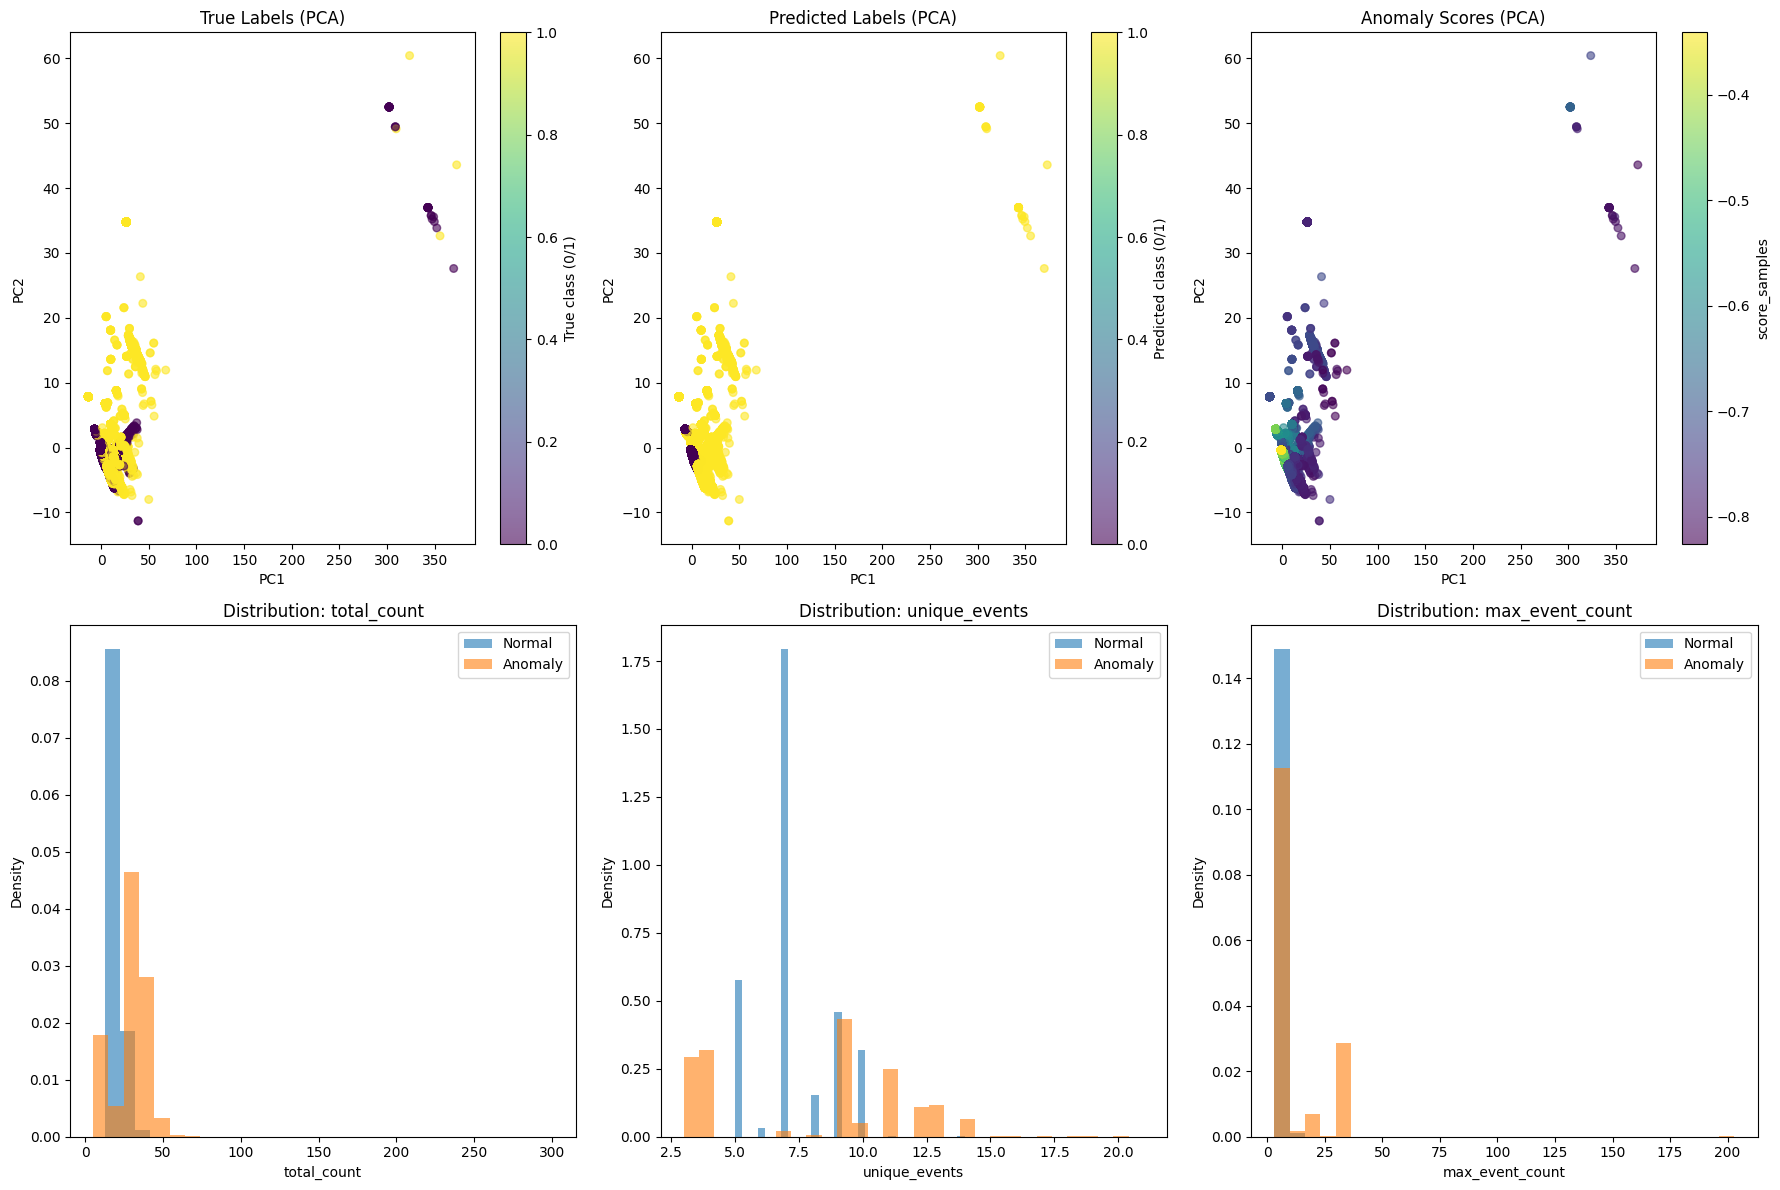

<Figure size 640x480 with 0 Axes>

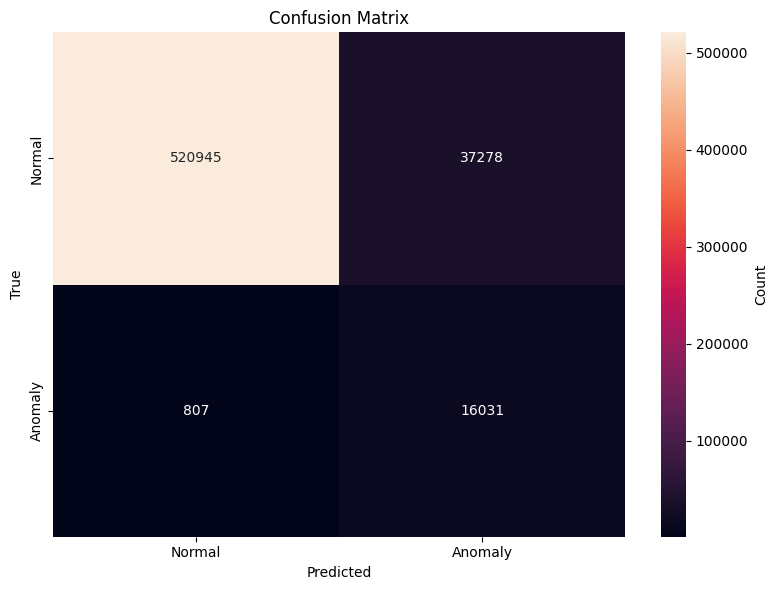

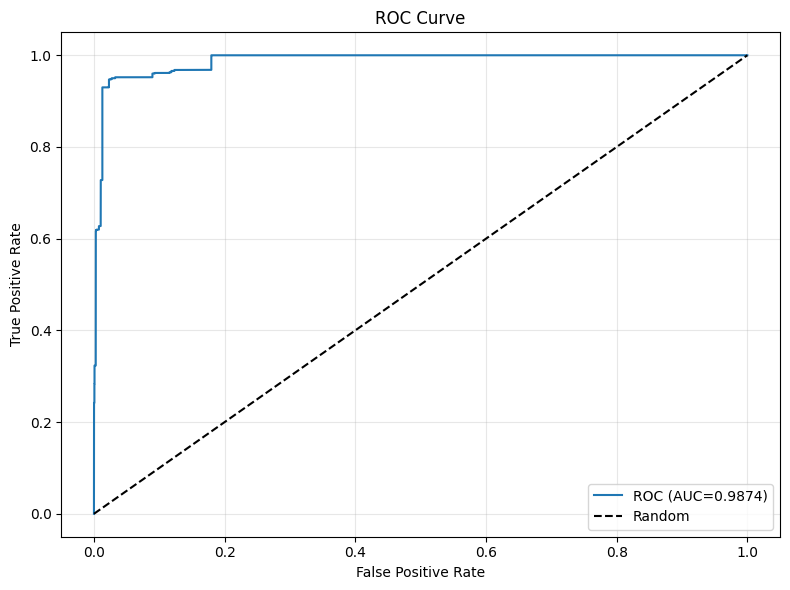

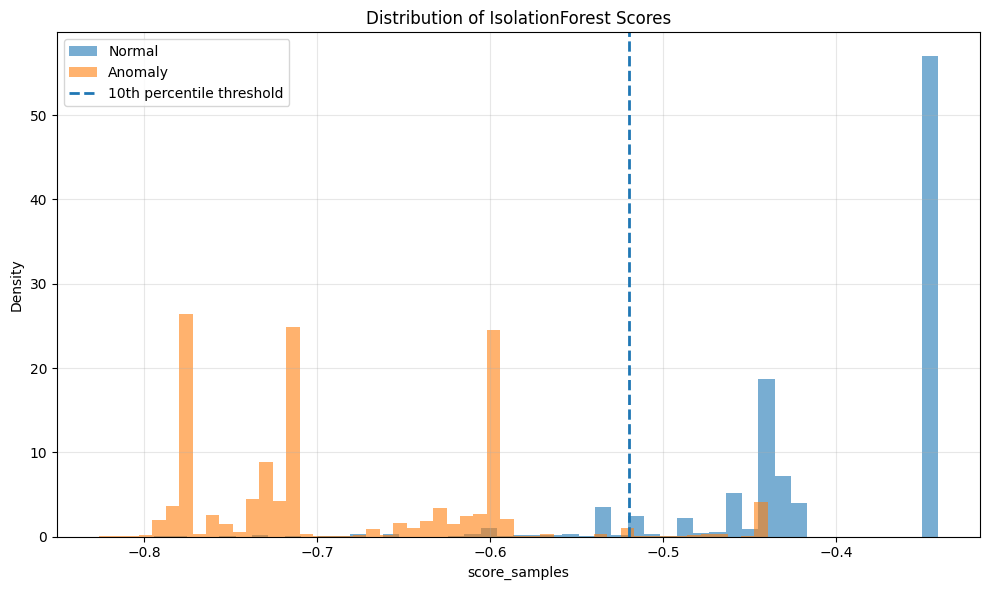

c:\Users\saied\miniconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\saied\miniconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


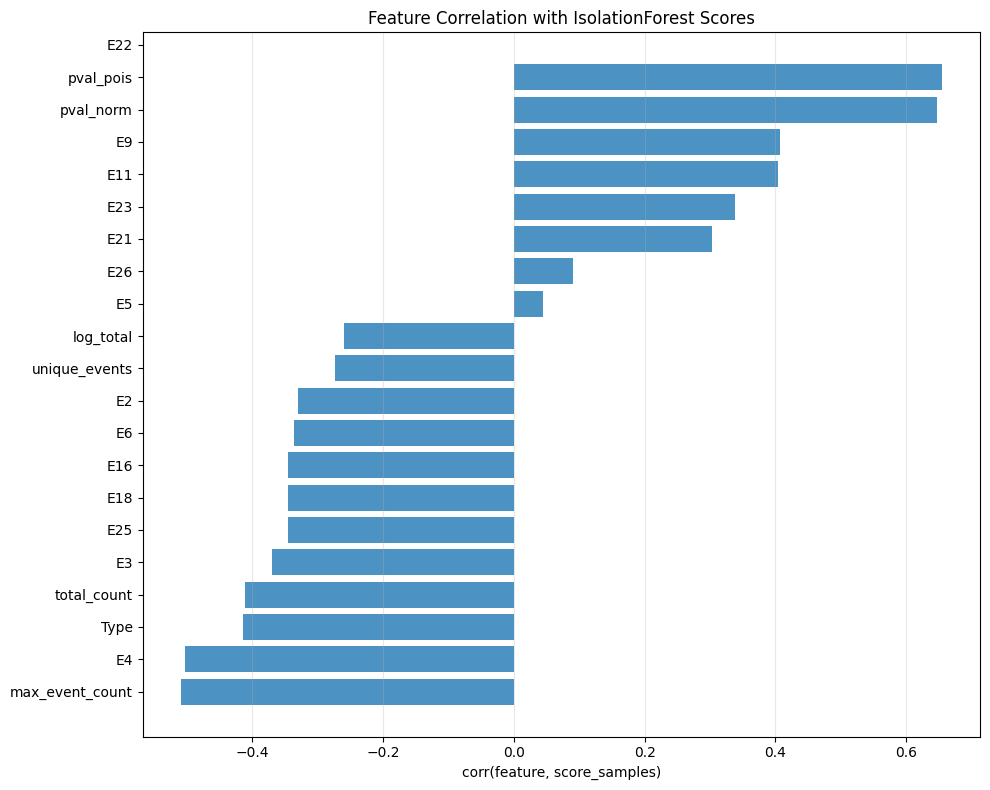


Visualizations saved to 'figures/' directory:
  - isolation_forest_results.png
  - isolation_forest_confusion_matrix.png
  - isolation_forest_roc_curve.png
  - isolation_forest_score_distribution.png
  - isolation_forest_feature_analysis.png

ANALYSIS COMPLETE



In [59]:
def main():
    """
    Main function to run Isolation Forest anomaly detection.
    """
    print("\n" + "="*60)
    print("ISOLATION FOREST FOR HDFS LOG ANOMALY DETECTION")
    print("="*60)
    
    X = df_feat[feat_cols].astype(float)
    y_true = df_feat["y"].astype(int)   
    
    print(f"Dataset shape: {X.shape}")
    print(f"Normal samples: {sum(y_true == 0)}")
    print(f"Anomalous samples: {sum(y_true == 1)}")
    print(f"Anomaly ratio: {sum(y_true == 1) / len(y_true):.2%}")
    
    # Display sample statistics
    print("\nFeature Statistics:")
    print("-"*60)
    print(X.describe())
    
    # Initialize and fit Isolation Forest
    print("\nTraining Isolation Forest model...")
    iso_forest = HDFSIsolationForest(
        contamination=0.1,
        random_state=42,
        n_estimators=100
    )
    
    # Fit and predict
    y_pred = iso_forest.fit_predict(X)
    anomaly_scores = iso_forest.anomaly_scores(X)
    
    # Evaluate performance
    print("\nEvaluating model performance...")
    metrics = iso_forest.evaluate_performance(y_true, y_pred, anomaly_scores)
    
    # Create visualizations
    print("\nGenerating visualizations...")
    visualize_results(X, y_true, y_pred, anomaly_scores, save_path='figures/')
    
    print("\nVisualizations saved to 'figures/' directory:")
    print("  - isolation_forest_results.png")
    print("  - isolation_forest_confusion_matrix.png")
    print("  - isolation_forest_roc_curve.png")
    print("  - isolation_forest_score_distribution.png")
    print("  - isolation_forest_feature_analysis.png")
    
    print("\n" + "="*60)
    print("ANALYSIS COMPLETE")
    print("="*60 + "\n")
    
    return iso_forest, metrics


if __name__ == "__main__":
    model, metrics = main()

In [56]:
%%capture cap
model, metrics = main()

import os
os.makedirs("results", exist_ok=True)

with open("results/main_output.txt", "w", encoding="utf-8") as f:
    f.write(cap.stdout)
    f.write("\n--- STDERR ---\n")
    f.write(cap.stderr)

print("saved:", os.path.abspath("results/main_output.txt"))

NameError: name 'cap' is not defined